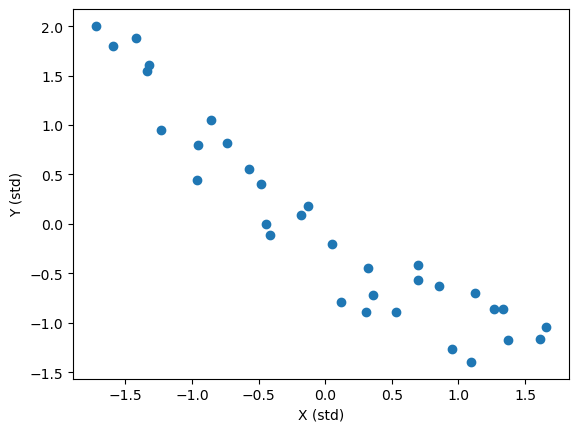

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, eps]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 38 seconds.


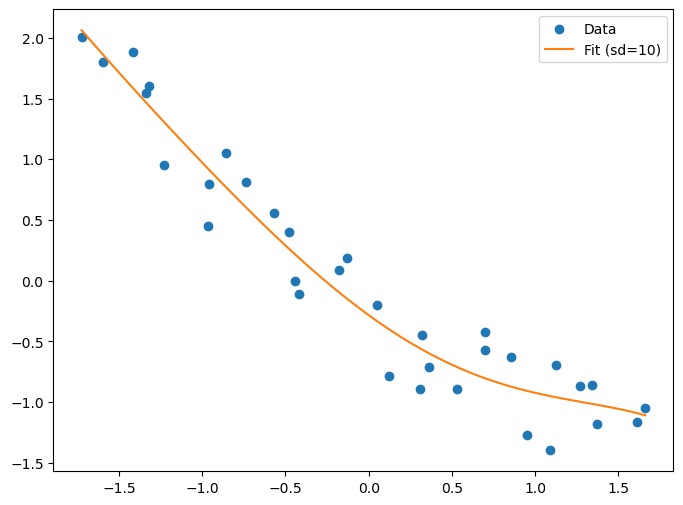

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, eps]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 36 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, eps]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 27 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, eps]


...

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, eps]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 24 seconds.


Output()

         rank  elpd_waic    p_waic  elpd_diff        weight        se  \
Model_2     0   9.105404  2.633108   0.000000  1.000000e+00  4.687281   
Model_3     1  10.980880  3.312261   1.875476  3.885781e-16  4.615347   
Model_1     2  28.609403  2.379245  19.503999  0.000000e+00  5.307702   

              dse  warning     scale  
Model_2  0.000000    False  deviance  
Model_3  0.688848    False  deviance  
Model_1  5.293856    False  deviance  


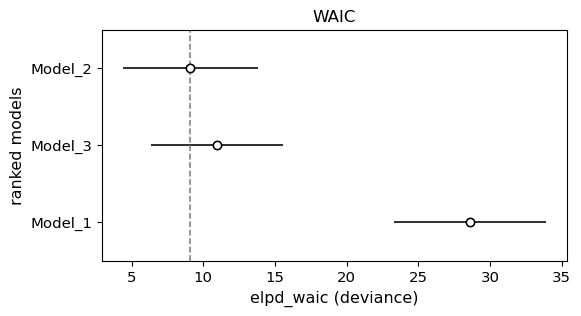

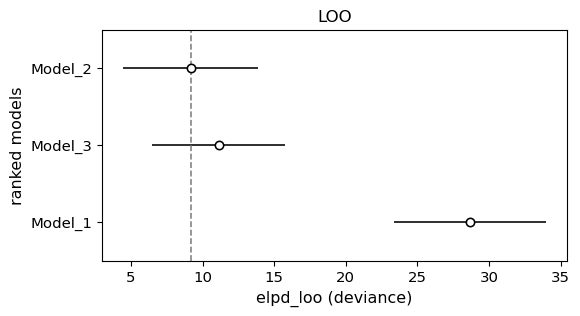

In [3]:
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import pandas as pd

df = pd.read_csv('date.csv', header=None, sep='\s+')
raw_x = df[0].values
raw_y = df[1].values

x_s = (raw_x - raw_x.mean()) / raw_x.std()
y_s = (raw_y - raw_y.mean()) / raw_y.std()

plt.scatter(x_s, y_s)
plt.xlabel('X (std)')
plt.ylabel('Y (std)')
plt.show()

deg = 5
x_matrix = np.vstack([x_s**k for k in range(1, deg+1)])

with pm.Model() as m_base:
    a = pm.Normal('a', mu=0, sigma=1)
    b = pm.Normal('b', mu=0, sigma=10, shape=deg)
    eps = pm.HalfNormal('eps', 5)
    
    trend = a + pm.math.dot(b, x_matrix)
    
    pm.Normal('obs', mu=trend, sigma=eps, observed=y_s)
    
    trace_base = pm.sample(2000, return_inferencedata=True, target_accept=0.9)

b_mean = trace_base.posterior['b'].mean(("chain", "draw")).values
a_mean = trace_base.posterior['a'].mean(("chain", "draw")).values

x_grid = np.linspace(x_s.min(), x_s.max(), 100)
x_grid_poly = np.vstack([x_grid**k for k in range(1, deg+1)])
y_grid_pred = a_mean + np.dot(b_mean, x_grid_poly)

plt.figure(figsize=(8, 6))
plt.scatter(x_s, y_s, label='Data')
plt.plot(x_grid, y_grid_pred, color='C1', label='Fit (sd=10)')
plt.legend()
plt.show()

with pm.Model() as m_loose:
    a = pm.Normal('a', mu=0, sigma=1)
    b = pm.Normal('b', mu=0, sigma=100, shape=deg)
    eps = pm.HalfNormal('eps', 5)
    
    trend = a + pm.math.dot(b, x_matrix)
    
    pm.Normal('obs', mu=trend, sigma=eps, observed=y_s)
    trace_loose = pm.sample(2000, return_inferencedata=True)

with pm.Model() as m_reg:
    a = pm.Normal('a', mu=0, sigma=1)
    
    s_vals = np.array([10, 0.1, 0.1, 0.1, 0.1]) 
    b = pm.Normal('b', mu=0, sigma=s_vals, shape=deg)
    
    eps = pm.HalfNormal('eps', 5)
    trend = a + pm.math.dot(b, x_matrix)
    
    pm.Normal('obs', mu=trend, sigma=eps, observed=y_s)
    trace_reg = pm.sample(2000, return_inferencedata=True)

n_samp = 500
x_new = np.linspace(-1.5, 1.5, n_samp)
y_new = -2.5 + 1.0 * x_new - 2.0 * x_new**2 + np.random.normal(0, 0.5, n_samp)

x_new_s = (x_new - x_new.mean()) / x_new.std()
y_new_s = (y_new - y_new.mean()) / y_new.std()

x_new_mat = np.vstack([x_new_s**k for k in range(1, 6)])

with pm.Model() as m_large:
    a = pm.Normal('a', mu=0, sigma=1)
    b = pm.Normal('b', mu=0, sigma=10, shape=5)
    eps = pm.HalfNormal('eps', 5)
    
    trend = a + pm.math.dot(b, x_new_mat)
    
    pm.Normal('obs', mu=trend, sigma=eps, observed=y_new_s)
    trace_large = pm.sample(2000, return_inferencedata=True)

x_ord1 = np.vstack([x_s**k for k in range(1, 2)])
x_ord2 = np.vstack([x_s**k for k in range(1, 3)])
x_ord3 = np.vstack([x_s**k for k in range(1, 4)])

with pm.Model() as m_1:
    a = pm.Normal('a', mu=0, sigma=1)
    b = pm.Normal('b', mu=0, sigma=10, shape=1)
    eps = pm.HalfNormal('eps', 5)
    
    trend = a + pm.math.dot(b, x_ord1)
    
    pm.Normal('obs', mu=trend, sigma=eps, observed=y_s)
    
    tr_1 = pm.sample(2000, return_inferencedata=True)
    pm.compute_log_likelihood(tr_1)

with pm.Model() as m_2:
    a = pm.Normal('a', mu=0, sigma=1)
    b = pm.Normal('b', mu=0, sigma=10, shape=2)
    eps = pm.HalfNormal('eps', 5)
    
    trend = a + pm.math.dot(b, x_ord2)
    
    pm.Normal('obs', mu=trend, sigma=eps, observed=y_s)
    
    tr_2 = pm.sample(2000, return_inferencedata=True)
    pm.compute_log_likelihood(tr_2)

with pm.Model() as m_3:
    a = pm.Normal('a', mu=0, sigma=1)
    b = pm.Normal('b', mu=0, sigma=10, shape=3)
    eps = pm.HalfNormal('eps', 5)
    
    trend = a + pm.math.dot(b, x_ord3)
    
    pm.Normal('obs', mu=trend, sigma=eps, observed=y_s)
    
    tr_3 = pm.sample(2000, return_inferencedata=True)
    pm.compute_log_likelihood(tr_3)

df_w = az.compare({
    'Model_1': tr_1, 
    'Model_2': tr_2, 
    'Model_3': tr_3
}, ic="waic", scale="deviance")

print(df_w)

az.plot_compare(df_w)
plt.title("WAIC")
plt.show()

df_l = az.compare({
    'Model_1': tr_1, 
    'Model_2': tr_2, 
    'Model_3': tr_3
}, ic="loo", scale="deviance")

az.plot_compare(df_l)
plt.title("LOO")
plt.show()